<a href="https://colab.research.google.com/github/epythonlab2/fintech-ml-labs/blob/main/Next_Gen_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Next-Gen Fraud Detection: Catching Deepfakes & Synthetic Identities with ML**

####**STEP 1: ENVIRONMENT SETUP**

In [ ]:
# Import Data Manipulation Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scikit-Learn Modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             roc_auc_score,
                             precision_recall_curve)

# Set visualization styles
sns.set_theme(style="whitegrid")
print("🚀 Workspace initialized successfully.")

🚀 Workspace initialized successfully.


####**STEP 2: PRODUCTION-GRADE TELEMETRY SIMULATION**

##### --- Genuine Human Footprints ---

In [ ]:
np.random.seed(42)
n_legitimate = 2200
n_fraudulent = 300

legit_data = {
    'credit_score': np.random.normal(loc=710, scale=60, size=n_legitimate).astype(int),
    'declared_income': np.random.normal(loc=85000, scale=20000, size=n_legitimate).astype(int),
    'form_completion_time_sec': np.random.exponential(scale=50, size=n_legitimate) + 20,
    'keystroke_latency_ms': np.random.normal(loc=160, scale=30, size=n_legitimate),
    'face_liveness_confidence': np.random.beta(a=8, b=2, size=n_legitimate)
}

##### --- Synthetic Identity/Deepfake Footprints ---

In [ ]:
fraud_data = {
    'credit_score': np.random.normal(loc=740, scale=40, size=n_fraudulent).astype(int),
    'declared_income': np.random.normal(loc=90000, scale=15000, size=n_fraudulent).astype(int),
    'form_completion_time_sec': np.random.exponential(scale=4, size=n_fraudulent) + 2,
    'keystroke_latency_ms': np.random.normal(loc=25, scale=8, size=n_fraudulent),
    'face_liveness_confidence': np.random.beta(a=2, b=5, size=n_fraudulent)
}


##### Combine into a unified production pipeline log

In [ ]:
df_legit = pd.DataFrame(legit_data).assign(is_fraud=0)
df_fraud = pd.DataFrame(fraud_data).assign(is_fraud=1)
df = pd.concat(
    [df_legit, df_fraud], ignore_index=True).sample(frac=1, random_state=42
    ).reset_index(drop=True)

print(f"📊 Dataset successfully structured with {df.shape[0]} applications.")

📊 Dataset successfully structured with 2500 applications.


##### Enforce realistic system boundaries


In [ ]:
df['credit_score'] = df['credit_score'].clip(300, 850)
df['form_completion_time_sec'] = df['form_completion_time_sec'].clip(lower=1.5)
df['keystroke_latency_ms'] = df['keystroke_latency_ms'].clip(lower=5)

print(df.shape)


(2500, 6)


In [ ]:
df.head()

,credit_score,declared_income,form_completion_time_sec,keystroke_latency_ms,face_liveness_confidence,is_fraud
0,745,89254,120.363500,159.076405,0.517174,0
1,719,77770,119.903397,180.968592,0.899582,0
2,688,98308,74.795583,182.423349,0.741844,0
3,766,84156,6.222155,22.783991,0.371819,1
4,678,81812,23.467027,145.479486,0.937558,0


####**STEP 3: EXPLORATORY DATA ANALYSIS (EDA)**

###### Plot 1 & 2


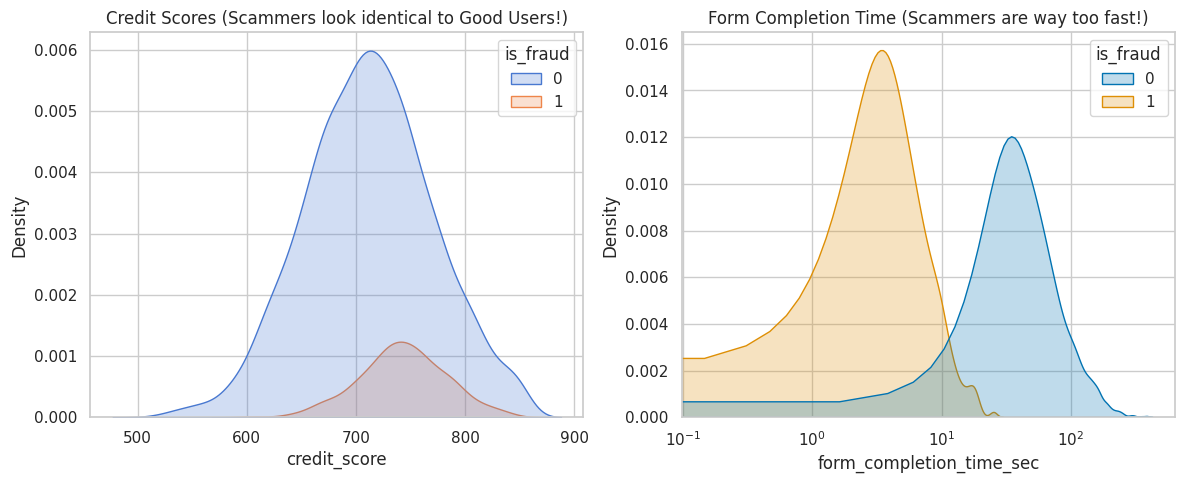

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Credit Scores look identical
sns.kdeplot(data=df, x='credit_score', hue='is_fraud', fill=True, ax=axes[0], palette="muted")
axes[0].set_title("Credit Scores (Scammers look identical to Good Users!)")

# Chart 2: Time shows the truth
sns.kdeplot(data=df, x='form_completion_time_sec', hue='is_fraud', fill=True, ax=axes[1], palette="colorblind")
axes[1].set_title("Form Completion Time (Scammers are way too fast!)")
axes[1].set_xscale('log')
plt.show()

#####**STEP 4: PREPROCESSING & TRAINING PIPELINE**


In [ ]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Using a Random Forest (a collection of smart decision trees)
model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)

print("🎯 Random Forest Fusion Engine trained and ready for validation.")

🎯 Random Forest Fusion Engine trained and ready for validation.


#####**STEP 5: EVALUATION MATRIX**

In [ ]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("📝 Evaluation Report:")
print(classification_report(y_test, y_pred))
print(f"📈 ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}\n")

📝 Evaluation Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       667
           1       0.99      1.00      0.99        83

    accuracy                           1.00       750
   macro avg       0.99      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750

📈 ROC-AUC Score: 1.0000



##### Compute and Plot Feature Importances

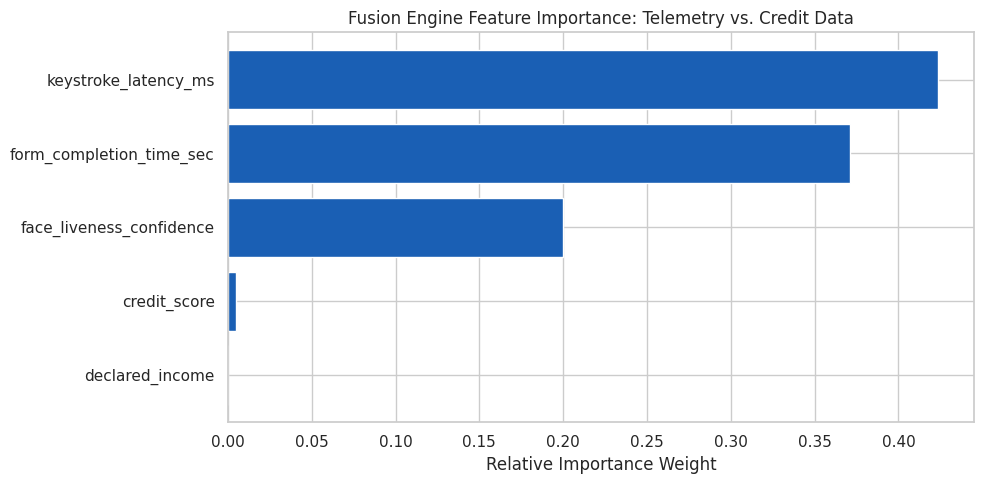

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices], color='#1a5fb4', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance Weight')
plt.title('Fusion Engine Feature Importance: Telemetry vs. Credit Data')
plt.tight_layout()
plt.show()